# Super Simple CNN Transfer Learning with ONNX Conversion

The goal of this notebook is to leverage the Google Colab Pro A100 GPU Runtime to quickly train a fine-tuned CNN using this oldie but goodie tutorial by PyTorch: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Make sure to download the classic ants and bees "hymenopetara_data" zip file.

The last cells are what I used this model for: to convert from Pytorch to ONNX file format. Note that after you convert the model, you can then download it from your Google Drive locally.

At that point, you should refer to `quantize.py` and `main.py` to INT8 quantize the ONNX model (because all ONNX conversion does is make the runtime faster, not inherently "shrink" the weights). Running the quantize script will quantize the model locally and then verify it.

You can then run `main.py` to run the model locally on your CPU.

In [ ]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_transforms = {
    'train': transforms.Compose([transforms.RandomResizedCrop(224),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
     'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = '/content/drive/MyDrive/AI/Kubernetes/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x), data_transforms[x]) for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


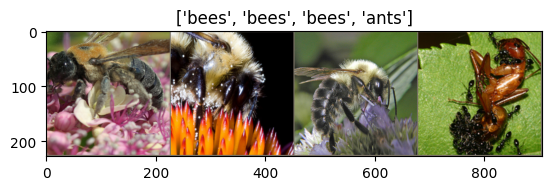

In [ ]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
      best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

      torch.save(model.state_dict(), best_model_params_path)
      best_acc = 0.0

      for epoch in range(num_epochs):
        print(f'Epoch{epoch}/{num_epochs - 1}')
        print("-" *10)

        for phase in ['train', 'val']:
          if phase == 'train':
            model.train()
          else:
            model.eval()

          running_loss = 0.0
          running_corrects = 0

          for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() #zero parameter gradients

            #forward pass
            with torch.set_grad_enabled(phase == 'train'):
              outputs = model(inputs)
              _, preds = torch.max(outputs,1)
              loss = criterion(outputs, labels)

              if phase == 'train':
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
          if phase == 'train':
            scheduler.step()


          epoch_loss = running_loss / dataset_sizes[phase]
          epoch_acc = running_corrects.double() / dataset_sizes[phase]

          print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

          #deep copy the model
          if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), best_model_params_path)

        print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        #load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))

      return model

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [ ]:
# Fine tune the CNN

model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1) # decay

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


In [ ]:
# train
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

Epoch0/24
----------
train Loss: 0.6147 Acc: 0.6844
val Loss: 0.2996 Acc: 0.8562

Training complete in 0m 19s
Best val Acc: 0.856209
Epoch1/24
----------
train Loss: 0.6170 Acc: 0.7254
val Loss: 0.7510 Acc: 0.7451

Training complete in 0m 21s
Best val Acc: 0.856209
Epoch2/24
----------
train Loss: 0.5189 Acc: 0.7828
val Loss: 0.2435 Acc: 0.9085

Training complete in 0m 23s
Best val Acc: 0.908497
Epoch3/24
----------
train Loss: 0.4741 Acc: 0.8197
val Loss: 0.2751 Acc: 0.8889

Training complete in 0m 24s
Best val Acc: 0.908497
Epoch4/24
----------
train Loss: 0.5021 Acc: 0.7992
val Loss: 0.3378 Acc: 0.8758

Training complete in 0m 26s
Best val Acc: 0.908497
Epoch5/24
----------
train Loss: 0.6035 Acc: 0.7951
val Loss: 0.2761 Acc: 0.8889

Training complete in 0m 28s
Best val Acc: 0.908497
Epoch6/24
----------
train Loss: 0.4893 Acc: 0.8156
val Loss: 0.1815 Acc: 0.9542

Training complete in 0m 29s
Best val Acc: 0.954248
Epoch7/24
----------
train Loss: 0.4089 Acc: 0.8074
val Loss: 0.1830 

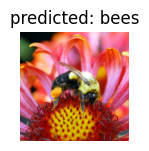

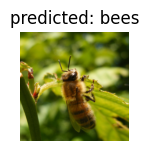

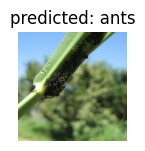

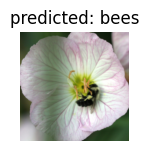

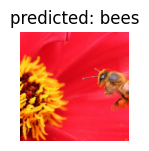

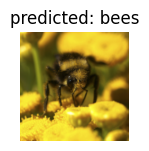

In [ ]:
visualize_model(model_ft)

In [ ]:
from math import exp
# freeze the base

model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
  param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# only parameters of FINAL LAYER are being optimized everything else is frozen
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

#decay learning rate
exp_lr_scheduler  = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
# fine-tune
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch0/24
----------
train Loss: 0.5860 Acc: 0.6844
val Loss: 0.2017 Acc: 0.9412

Training complete in 0m 2s
Best val Acc: 0.941176
Epoch1/24
----------
train Loss: 0.4913 Acc: 0.7582
val Loss: 0.2386 Acc: 0.8954

Training complete in 0m 3s
Best val Acc: 0.941176
Epoch2/24
----------
train Loss: 0.4668 Acc: 0.7828
val Loss: 0.1896 Acc: 0.9281

Training complete in 0m 5s
Best val Acc: 0.941176
Epoch3/24
----------
train Loss: 0.6239 Acc: 0.7377
val Loss: 0.1924 Acc: 0.9412

Training complete in 0m 6s
Best val Acc: 0.941176
Epoch4/24
----------
train Loss: 0.3940 Acc: 0.8238
val Loss: 0.2540 Acc: 0.9281

Training complete in 0m 7s
Best val Acc: 0.941176
Epoch5/24
----------
train Loss: 0.5507 Acc: 0.7582
val Loss: 0.2535 Acc: 0.9020

Training complete in 0m 9s
Best val Acc: 0.941176
Epoch6/24
----------
train Loss: 0.6478 Acc: 0.7336
val Loss: 0.2631 Acc: 0.9020

Training complete in 0m 10s
Best val Acc: 0.941176
Epoch7/24
----------
train Loss: 0.3526 Acc: 0.8443
val Loss: 0.2127 Acc: 0

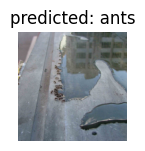

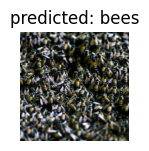

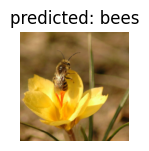

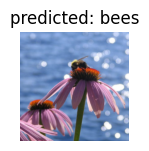

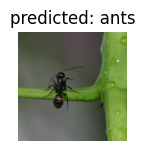

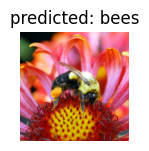

In [ ]:
visualize_model(model_conv)

In [ ]:
 print(model_conv)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
! pip install torchviz

torch.Size([1, 3, 224, 224])


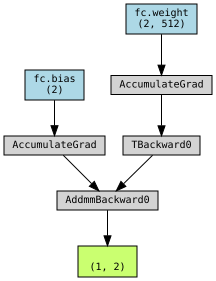

In [ ]:
# visualize with torchviz

from torchviz import make_dot
from IPython.display import display


# single batch
inputs, labels = next(iter(dataloaders['val']))
single_input = inputs[0:1].to(device)
print(single_input.size())
single_label = labels[0:1].to(device)

#with torch.no_grad(): #<- don't use torch.no_grad() b/c this prevents PyTorch from building hte whoel computational graph
output = model_conv(single_input)

dot = make_dot(output, params=dict(model_conv.named_parameters()))

dot #[1,2] means 1 batch, 2 classes (bees, ants)


In [ ]:
# custom images
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

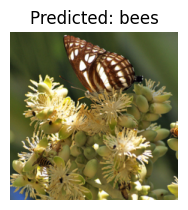

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='/content/drive/MyDrive/AI/Kubernetes/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

In [ ]:
PATH = '/content/drive/MyDrive/AI/Kubernetes/model_weights.pth'

In [ ]:
torch.save(model_conv.state_dict(), PATH)

In [ ]:
# load

my_model = model_conv
my_model.load_state_dict(torch.load(PATH))
my_model.eval() # set to evaluate mode
print("Loaded successfully {} state dict".format(my_model))


Loaded successfully ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

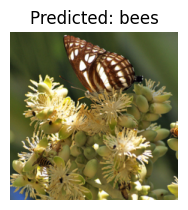

In [ ]:
# does it work - YES

visualize_model_predictions(
    my_model, #<--- YES
    img_path='/content/drive/MyDrive/AI/Kubernetes/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

In [ ]:
file_size_bytes = os.path.getsize(PATH)
file_size_mb = file_size_bytes / (1024 * 1024)
print(file_size_mb)

42.71522045135498


**Because I want to run this on my CPU, I need to convert it to an ONNX model.**



ONNX Models Are NOT Necessarily Smaller in File Size
The model file size (42.7MB vs 42.6MB) is essentially the same
because:

Both store the same weights - The bulk of the file size comes from the model's parameters (weights and biases). ONNX doesn't compress these by default.


ONNX stores the computation graph - It replaces PyTorch's code with a serialized graph representation, but this is relatively small compared to the weights.
No automatic compression - ONNX export doesn't apply quantization or pruning unless you explicitly do so.

What ONNX does:



*   Smaller runtime footprint: ~ 10 - 50 MB compared to Full PyTorch installation of ~ 700 - 1000 MB
*   Optimized execution graph for faster inference (and better performance on CPU)
* Portability, no PyTorch dependence
* Production-ready, designed for deployment not training


To make the model physically SMALLER, you need to quantize it.



In [ ]:
!pip install --upgrade onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.0/680.0 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.5/127.5 kB 12.3 MB/s eta 0:00:00


In [ ]:
# create a dummy input tensor to trace the model's computation graph , should have the same dummy input (tensor.size()) as real data
# torch.Size([1, 3, 224, 224])

#move model to CPU first, or there will be a device mismatch
my_model = my_model.to('cpu')

dummy_input = torch.randn(1, 3, 224, 224, device='cpu')

# export to ONNX via PyTorch built in conversion
# this already saves it to onnx_model.onnx
onnx_model = torch.onnx.export(my_model,
                  dummy_input,
                  "/content/drive/MyDrive/AI/Kubernetes/my_model.onnx", #<---- SAVES IT HERE
                  export_params=True,
                  opset_version=11,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'},
                                'output': {0: 'batch_size'}}
                  )

/tmp/ipython-input-1102105096.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  onnx_model = torch.onnx.export(my_model,


In [ ]:

import onnx

# Load the ONNX model
onnx_model = onnx.load("my_model.onnx")

# Check that the model is well formed
onnx.checker.check_model(onnx_model)

print("ONNX model is valid!")
print(onnx.helper.printable_graph(onnx_model.graph))

ONNX model is valid!
graph main_graph (
  %input[FLOAT, batch_sizex3x224x224]
) initializers (
  %fc.weight[FLOAT, 2x512]
  %fc.bias[FLOAT, 2]
  %onnx::Conv_193[FLOAT, 64x3x7x7]
  %onnx::Conv_194[FLOAT, 64]
  %onnx::Conv_196[FLOAT, 64x64x3x3]
  %onnx::Conv_197[FLOAT, 64]
  %onnx::Conv_199[FLOAT, 64x64x3x3]
  %onnx::Conv_200[FLOAT, 64]
  %onnx::Conv_202[FLOAT, 64x64x3x3]
  %onnx::Conv_203[FLOAT, 64]
  %onnx::Conv_205[FLOAT, 64x64x3x3]
  %onnx::Conv_206[FLOAT, 64]
  %onnx::Conv_208[FLOAT, 128x64x3x3]
  %onnx::Conv_209[FLOAT, 128]
  %onnx::Conv_211[FLOAT, 128x128x3x3]
  %onnx::Conv_212[FLOAT, 128]
  %onnx::Conv_214[FLOAT, 128x64x1x1]
  %onnx::Conv_215[FLOAT, 128]
  %onnx::Conv_217[FLOAT, 128x128x3x3]
  %onnx::Conv_218[FLOAT, 128]
  %onnx::Conv_220[FLOAT, 128x128x3x3]
  %onnx::Conv_221[FLOAT, 128]
  %onnx::Conv_223[FLOAT, 256x128x3x3]
  %onnx::Conv_224[FLOAT, 256]
  %onnx::Conv_226[FLOAT, 256x256x3x3]
  %onnx::Conv_227[FLOAT, 256]
  %onnx::Conv_229[FLOAT, 256x128x1x1]
  %onnx::Conv_230[FLO

/tmp/ipython-input-1651785274.py:10: DeprecationWarning: Deprecated since 1.19. Consider using onnx.printer.to_text() instead.
  print(onnx.helper.printable_graph(onnx_model.graph))
